# Forget

In [1]:
import os
os.chdir("/home/weiren/Figure")

/tmp/ipykernel_201681/794355908.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='Test_R2', data=data_melted, ax=ax2,


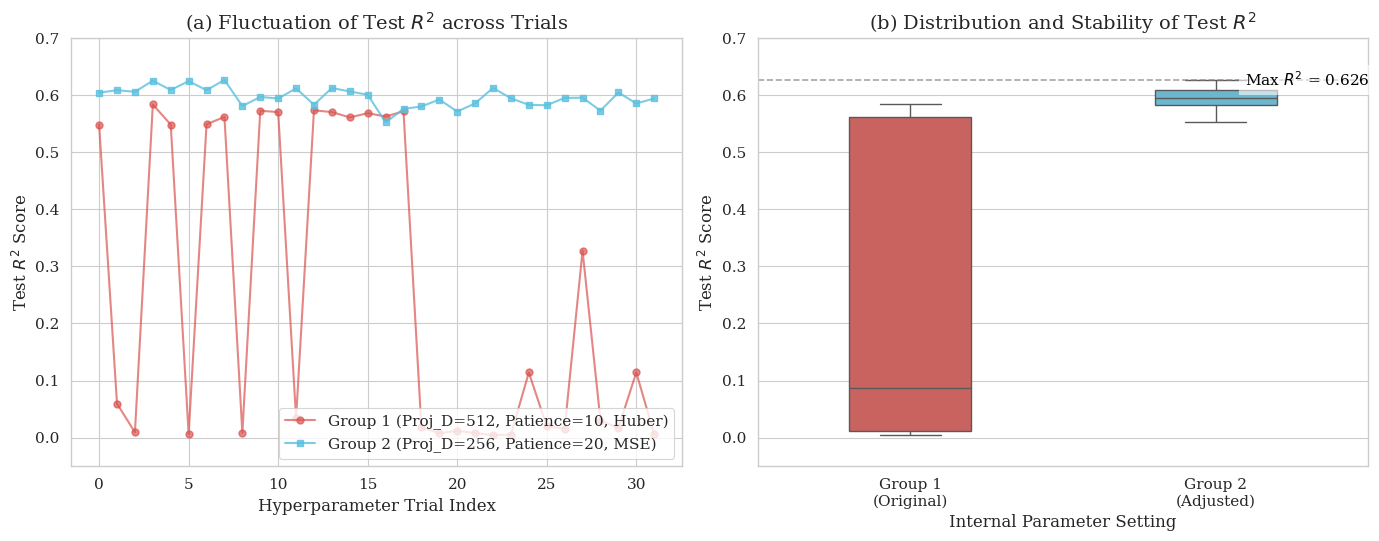

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 数据加载与预处理
# 请确保 excel 文件与 jupyter notebook 处于同一目录下
file_path = "hyperparameters.xlsx"
df = pd.read_excel(file_path)

# 提取两组实验的 TEST_R2 数据并去除空值对齐数据长度
# TEST_R2 对应第一组参数，TEST_R2.1 对应第二组参数
df_clean = df[['TEST_R2', 'TEST_R2.1']].dropna()

# 2. 设置科研论文绘图风格
# 使用 seaborn 的 whitegrid 风格，更显专业和整洁
plt.style.use('default')
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams['font.family'] = 'serif'  # 论文通常使用衬线字体，如 Times New Roman
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11

# 创建 1x2 的子图组合 (Fig 1a 和 Fig 1b)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# --- Subplot 1 (Left): 折线/散点图展示性能的波动与骤降 ---
# 使用不同的 marker 和颜色进行区分
ax1.plot(df_clean['TEST_R2'].values, marker='o', linestyle='-', color='#d9534f', 
         alpha=0.7, markersize=5, linewidth=1.5, label='Group 1 (Proj_D=512, Patience=10, Huber)')
ax1.plot(df_clean['TEST_R2.1'].values, marker='s', linestyle='-', color='#5bc0de', 
         alpha=0.8, markersize=5, linewidth=1.5, label='Group 2 (Proj_D=256, Patience=20, MSE)')

ax1.set_xlabel('Hyperparameter Trial Index')
ax1.set_ylabel('Test $R^2$ Score')
ax1.set_title('(a) Fluctuation of Test $R^2$ across Trials')
ax1.legend(loc='lower right', frameon=True, shadow=False)
ax1.set_ylim(-0.05, 0.7)

# --- Subplot 2 (Right): 箱线图展示数据分布的稳定性和上限 ---
# 将数据重塑为长格式以使用 seaborn 绘制精美箱线图
data_melted = pd.melt(df_clean, value_vars=['TEST_R2', 'TEST_R2.1'], 
                      var_name='Group', value_name='Test_R2')
data_melted['Group'] = data_melted['Group'].replace({
    'TEST_R2': 'Group 1\n(Original)', 
    'TEST_R2.1': 'Group 2\n(Adjusted)'
})

sns.boxplot(x='Group', y='Test_R2', data=data_melted, ax=ax2, 
            palette=['#d9534f', '#5bc0de'], width=0.4, fliersize=4)

ax2.set_xlabel('Internal Parameter Setting')
ax2.set_ylabel('Test $R^2$ Score')
ax2.set_title('(b) Distribution and Stability of Test $R^2$')
ax2.set_ylim(-0.05, 0.7)

# 添加最高性能标注 (0.626)
max_r2 = df_clean['TEST_R2.1'].max()
ax2.axhline(y=max_r2, color='gray', linestyle='--', alpha=0.7)
ax2.text(x=1.3, y=max_r2, s=f'Max $R^2$ = {max_r2:.3f}', va='center', ha='center', 
         fontsize=11, color='black', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

# 3. 布局调整与高质量保存
plt.tight_layout()
# 论文通常要求 300 或 600 DPI 的高质量图片
plt.savefig('hyperparameter_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Model Learning Curve

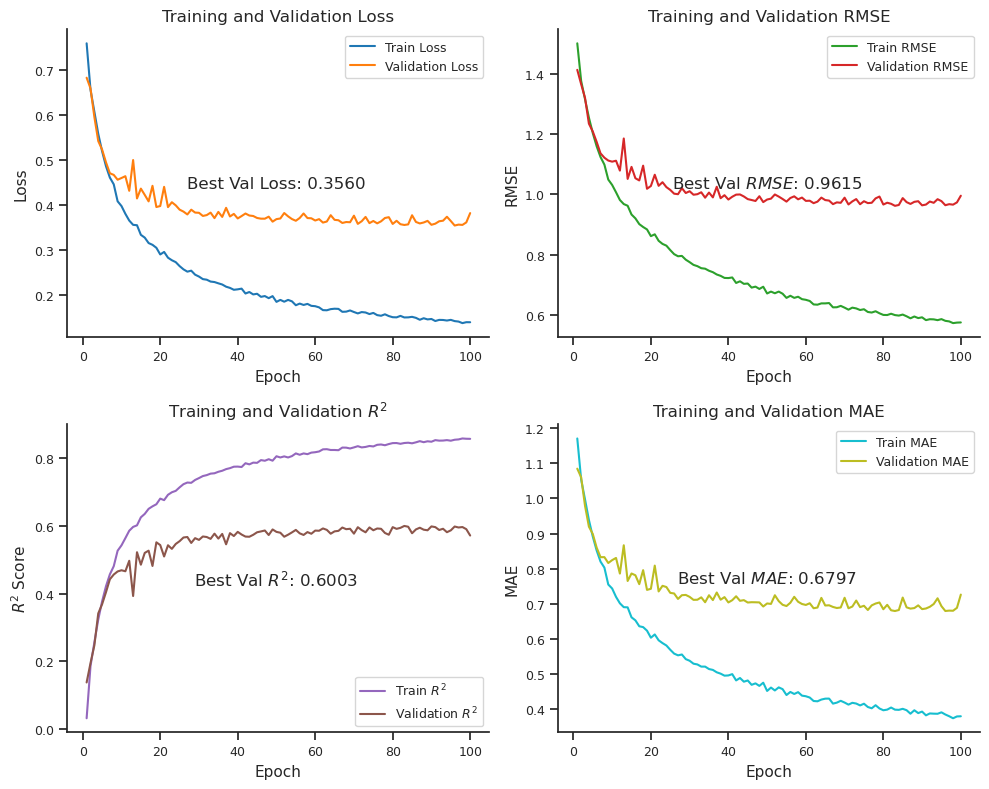

In [7]:
# style settings
sns.set(style="ticks")
plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.figsize": (10, 8),
    "lines.linewidth": 1.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# data loading
df = pd.read_csv("./Interkcat/training_metrics.csv")
best_epoch_idx = df['Val_R2'].idxmax()
best_row = df.loc[best_epoch_idx]
best_epoch = int(best_row['Epoch'])
df['Epoch'] = df['Epoch'].astype(int)

# draw plots
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.tight_layout(pad=3.0)

# 1. Loss
axes[0, 0].plot(df['Epoch'], df['Train_Loss'], label='Train Loss', color='tab:blue')
axes[0, 0].plot(df['Epoch'], df['Val_Loss'], label='Validation Loss', color='tab:orange')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].set_title('Training and Validation Loss')

ax = axes[0, 0]
x_center = df.shape[0] / 2.0
y_min, y_max = ax.get_ylim()
y_center = (y_min + y_max) / 2.0
ax.text(x_center, y_center,
        f"Best Val Loss: {best_row['Val_Loss']:.4f}",
        va='center', ha='center',
        fontsize=12)

# 2. RMSE
axes[0, 1].plot(df['Epoch'], df['Train_RMSE'], label='Train RMSE', color='tab:green')
axes[0, 1].plot(df['Epoch'], df['Val_RMSE'], label='Validation RMSE', color='tab:red')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('RMSE')
axes[0, 1].legend()
axes[0, 1].set_title('Training and Validation RMSE')

ax = axes[0, 1]
x_center = df.shape[0] / 2.0
y_min, y_max = ax.get_ylim()
y_center = (y_min + y_max) / 2.0
ax.text(x_center, y_center,
        f"Best Val $RMSE$: {best_row['Val_RMSE']:.4f}",
        va='center', ha='center',
        fontsize=12)

# 3. R²
axes[1, 0].plot(df['Epoch'], df['Train_R2'], label=r'Train $R^2$', color='tab:purple')
axes[1, 0].plot(df['Epoch'], df['Val_R2'], label=r'Validation $R^2$', color='tab:brown')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel(r'$R^2$ Score')
axes[1, 0].legend()
axes[1, 0].set_title(r'Training and Validation $R^2$')

ax = axes[1, 0]
x_center = df.shape[0] / 2.0
y_min, y_max = ax.get_ylim()
y_center = (y_min + y_max) / 2.0
ax.text(x_center, y_center,
        f"Best Val $R^2$: {best_row['Val_R2']:.4f}",
        va='center', ha='center',
        fontsize=12)

# 4. MAE
axes[1, 1].plot(df['Epoch'], df['Train_MAE'], label='Train MAE', color='tab:cyan')
axes[1, 1].plot(df['Epoch'], df['Val_MAE'], label='Validation MAE', color='tab:olive')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('MAE')
axes[1, 1].legend()
axes[1, 1].set_title('Training and Validation MAE')

ax = axes[1, 1]
x_center = df.shape[0] / 2.0
y_min, y_max = ax.get_ylim()
y_center = (y_min + y_max) / 2.0
ax.text(x_center, y_center,
        f"Best Val $MAE$: {best_row['Val_MAE']:.4f}",
        va='center', ha='center',
        fontsize=12)

plt.tight_layout()
plt.savefig("training_metrics_sci_style.png", dpi=600, bbox_inches='tight', transparent=True) # save figure
plt.show()

--- 数据集基础信息 ---
总数据量: 34140

Value (Kcat) 描述性统计:
count    3.414000e+04
mean     1.753778e+03
std      4.964025e+04
min      1.570000e-07
25%      3.357500e-01
50%      3.800000e+00
75%      3.300000e+01
max      5.000000e+06
Name: Value, dtype: float64


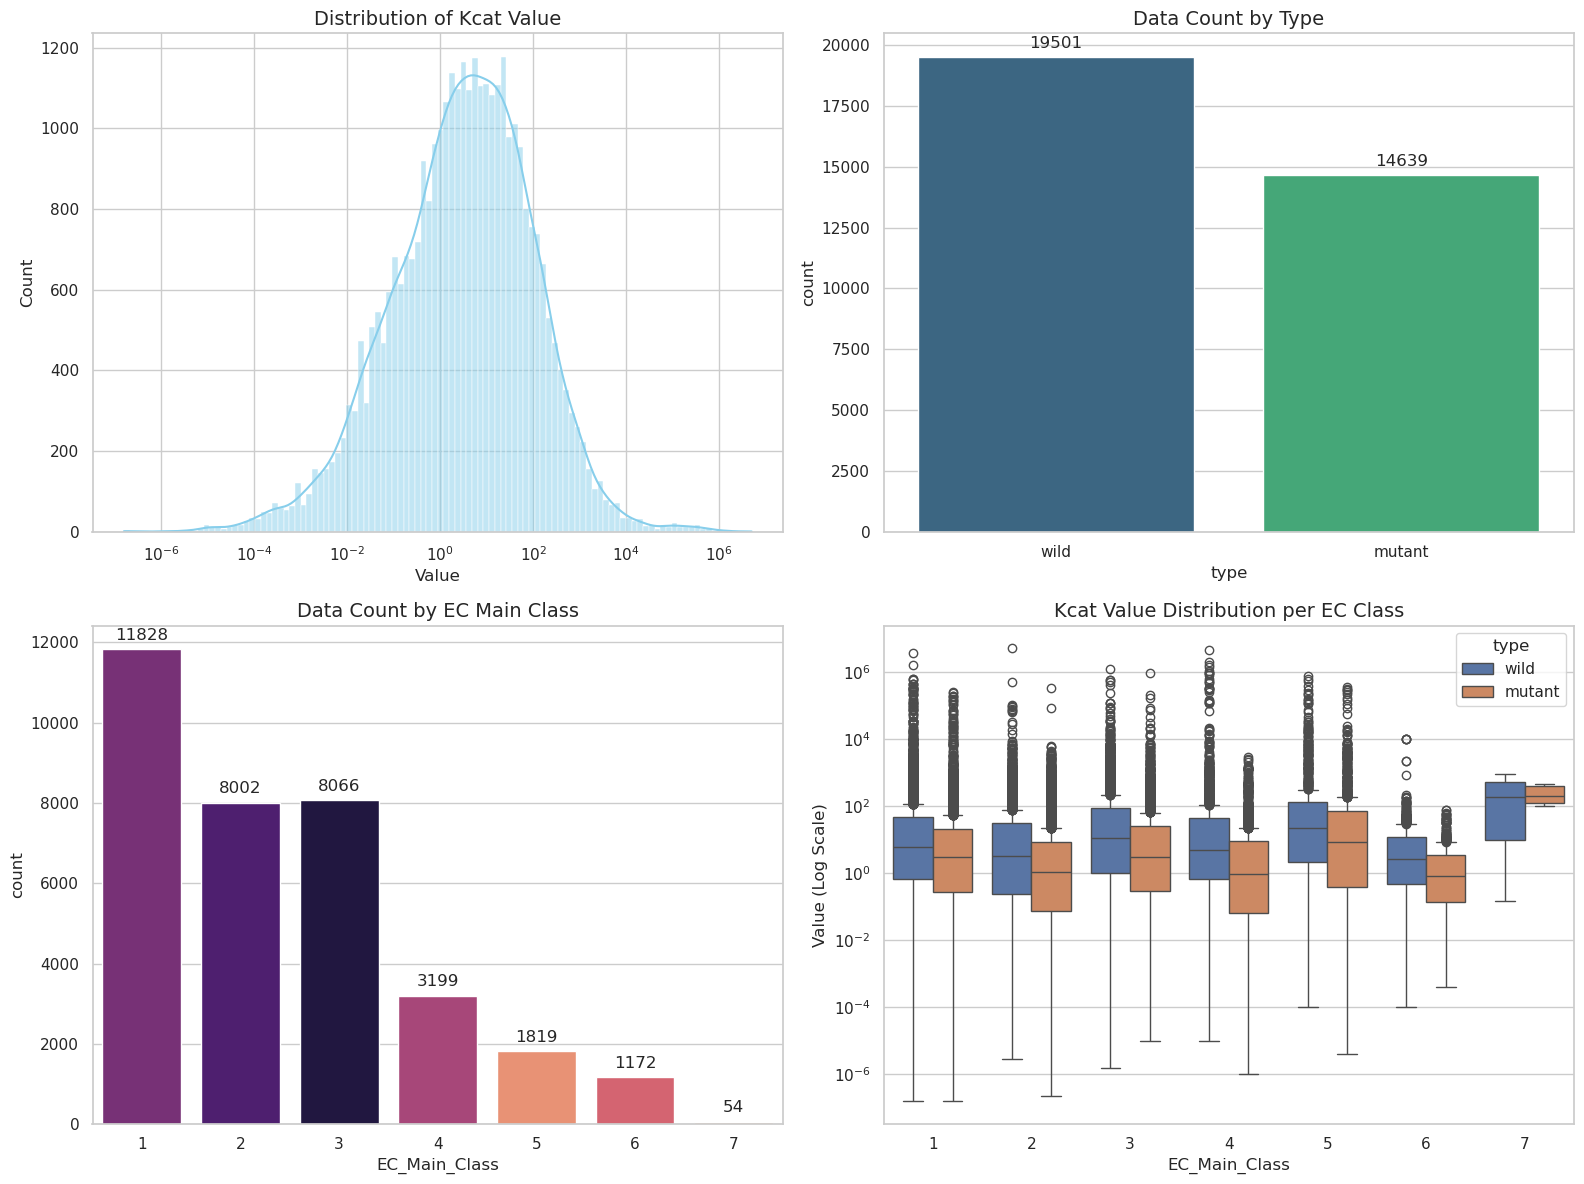


--- 类别与数据类型交叉统计表 ---
type           mutant  wild
EC_Main_Class              
1                4730  7098
2                4014  3988
3                2639  5427
4                1737  1462
5                1002   817
6                 497   675
7                  20    34


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 加载数据
df = pd.read_csv('./Interkcat/EITLEM_KCAT.csv')

# 2. 数据预处理
# 提取 EC Number 的第一位，并转换为整数/字符串进行排序
df['EC_Main_Class'] = df['ECNumber'].astype(str).str[0]

# 3. 基础统计信息打印
print("--- 数据集基础信息 ---")
print(f"总数据量: {len(df)}")
print("\nValue (Kcat) 描述性统计:")
print(df['Value'].describe())

# 设置绘图风格，解决字体缺失问题
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Liberation Sans', 'sans-serif'] 
plt.rcParams['axes.unicode_minus'] = False 

# 创建一个多图画布
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- 图 1: Value (Kcat) 的对数分布图 ---
# 酶活数据通常呈长尾分布，对数化后更符合正态分布特征
sns.histplot(df['Value'], kde=True, ax=axes[0, 0], log_scale=True, color='skyblue')
axes[0, 0].set_title('Distribution of Kcat Value', fontsize=14)
axes[0, 0].set_xlabel('Value')

# --- 图 2: 不同 Type 的数量统计 ---
# 修复 FutureWarning: 分配 x 到 hue 并设置 legend=False
ax2 = sns.countplot(data=df, x='type', hue='type', ax=axes[0, 1], palette='viridis', legend=False)
axes[0, 1].set_title('Data Count by Type', fontsize=14)
for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

# --- 图 3: EC Main Class (第一位) 的数量分布 ---
ec_order = sorted(df['EC_Main_Class'].unique())
ax3 = sns.countplot(data=df, x='EC_Main_Class', hue='EC_Main_Class', order=ec_order, 
                    ax=axes[1, 0], palette='magma', legend=False)
axes[1, 0].set_title('Data Count by EC Main Class', fontsize=14)
for p in ax3.patches:
    ax3.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

# --- 图 4: 不同 EC 分类下的 Kcat 值分布 (Boxplot) ---
# 这里换成箱线图能更好地观察不同 EC 类别的 Kcat 差异
sns.boxplot(data=df, x='EC_Main_Class', y='Value', hue='type', order=ec_order, ax=axes[1, 1])
axes[1, 1].set_yscale('log') # 纵轴采用对数坐标
axes[1, 1].set_title('Kcat Value Distribution per EC Class', fontsize=14)
axes[1, 1].set_ylabel('Value (Log Scale)')

plt.tight_layout()
plt.show()

# 4. 输出各类别的具体数值矩阵
print("\n--- 类别与数据类型交叉统计表 ---")
summary_table = pd.crosstab(df['EC_Main_Class'], df['type'])
print(summary_table)